In [2]:
pip install dataretrieval

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pyproj
from pyproj import Transformer
import osmnx as ox
import folium
import contextily as ctx
import dataretrieval.nwis as nwis # use to pull from USGS
from shapely.geometry import Point
import requests
import easysnowdata
import rioxarray as rxr
import shapely
from shapely.geometry import box
import dask
import pystac_client
import planetary_computer
import odc.stac
import datetime
import rasterio as rio

In [4]:
# create geodataframe of Olympic National Park boundaries
onp = "Olympic National Park, Washington, USA"
onp_gdf = ox.geocode_to_gdf(onp)

# create geodataframe of ONP Trails within park boundaries
trails_gdf = ox.features.features_from_polygon(onp_gdf.geometry.iloc[0], {'highway': 'path'})

In [5]:
# convert to UTM 10N crs
onp_gdf = onp_gdf.to_crs('EPSG: 32610')
trails_gdf = trails_gdf.to_crs('EPSG: 32610')

In [6]:
# create geodataframe of ONP and surrounding area Rivers
# maybe better to use open street maps?

# calling in the data from the Nationwide River Inventory (NRI) 
# used AI to help with API. It added the params and request part since calling in the url only brought in 1000 rivers, which didn't include those in ONP
rivers_url = "https://services1.arcgis.com/fBc8EJBxQRMcHlei/arcgis/rest/services/Nationwide_Rivers_Inventory_Official/FeatureServer/0/query"

params = {
    "where": """Management_Area_Name IN ('Olympic National Park', 'Olympic National Forest', 'Olympic National Park, Olympic National Forest',
                'The Brothers Wilderness')
            OR River LIKE '%Bogachiel%'""",
        "outFields": "*",
        "f": "geojson"}

r = requests.get(rivers_url, params=params)
rivers_gdf = gpd.read_file(r.text)

# convert to UTM 10N crs
rivers_gdf = rivers_gdf.to_crs('EPSG:32610')

In [7]:
# create a geodataframe of USGS stations
# add USGS station locations - code from streamflow notebook

station_id = stations = [12045500, 12054000, 12056500, 12039500, 12042800, 12041200, 12040500, 12043000, 12048000]
stations_gdf = gpd.GeoDataFrame(station_id, columns=['station_id'])
stations_gdf.index = ['Elwha River', 'Duckabush River', 'NF Skokomish River', 'Quinalt River', 'Bogachiel River', 'Hoh River',
                    'Queets River', 'Calawah River', 'Dungeness River']
geom = []
# the 'dec_lat_va' and 'dec_long_va' were taken from AI since it was helping to navigate the USGS API
for station in station_id:
    coords = nwis.get_record(sites=str(station), service="site")
    lat = coords.iloc[0]['dec_lat_va'] 
    lon = coords.iloc[0]['dec_long_va']
    geom.append(Point(lon, lat))
    
stations_gdf['geometry'] = geom
stations_gdf.set_geometry(stations_gdf['geometry'])
# set crs given on the USGS site
stations_gdf = stations_gdf.set_crs('EPSG:4267')
# convert to UTM 10N crs
stations_gdf = stations_gdf.to_crs('EPSG:32610')

/tmp/ipykernel_100/3075810099.py:16: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  stations_gdf['geometry'] = geom


In [8]:
# tried pulling from the API, but was unsuccessful after ~ an hour of troubleshooting, so I elected to just download the file

watersheds_gdf = gpd.read_file("data/NHD_-9030064575332258501.geojson")
# convert to onp_gdf crs
watersheds_gdf = watersheds_gdf.to_crs(onp_gdf.crs)

In [9]:
# set x and y limits of the plot
bounds = onp_gdf.total_bounds
xmin, xmax, ymin, ymax = bounds[0], bounds[2], bounds[1], bounds[3]
buffer = 10000

In [10]:
# I was unable to add the ONP boundary to the plot's legend, this fix from a github discussion forum: https://github.com/geopandas/geopandas/issues/660

from matplotlib.legend import Legend
from matplotlib.collections import PatchCollection
from matplotlib.legend_handler import HandlerPolyCollection

Legend.update_default_handler_map({PatchCollection: HandlerPolyCollection()})

## 2020 RGB

In [11]:
# Converting bounds used for vector data in 32610 to lat long coordinates for easysnowdata input
transformer = Transformer.from_crs('EPSG:32610', 'EPSG: 4326', always_xy=True)

xmin, ymin, xmax, ymax = bounds

lon_min, lat_min = transformer.transform(xmin, ymin)
lon_max, lat_max = transformer.transform(xmax, ymax)
#bbox = [lon_min, lat_min, lon_max, lat_max]  # Needs to be a geometry object for easysnowdata
bbox_geom = box(lon_min, lat_min, lon_max, lat_max)

In [14]:
bbox = (-124.4,47.45,-123,48.06)  # Rough bounds of ONP

s2_2020 = easysnowdata.remote_sensing.Sentinel2(
    bbox_input=bbox_geom,
    start_date="2020-07-15",
    end_date="2020-08-15",
    catalog_choice="planetarycomputer",
    resolution=80,
)

#Defaults to: No Data, Saturated pixels, topographic shadows, cloud shadows, cloud medium probability, cloud high probability and thin cirrus, , which are all then removed
s2_2020.mask_data()

s2_2020.get_rgb()

rgb_median_composite_2020 = s2_2020.rgb_clahe.median(dim='time').compute()  

Data searched. Access the returned seach with the .search attribute.
Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.
Nodata values removed from the data. In doing so, all bands converted to float32. To turn this behavior off, set remove_nodata=False.
Data acquired after January 25th, 2022 harmonized to old baseline. To override this behavior, set harmonize_to_old=False.
Data scaled to float reflectance. To turn this behavior off, set scale_data=False.
Metadata retrieved. Access with the .metadata attribute.
Removed pixels with the following scene classification values:
No Data (Missing data)
Saturated or defective pixel
Topographic casted shadows
Cloud shadows
Cloud medium probability
Cloud high probability
Thin cirrus
RGB data retrieved.
Access with the following attributes:
.rgb for raw RGB,
.rgba for RGBA,
.rgb_percentile for percentile RGB,
.rgb_clahe for CLAHE RGB.
You can pass in percentile_kwargs and clahe_kwargs to adjust RGB calculations, chec

In [26]:
# get snow extents - there are some clear outliers that are present in the water!
s2_2020.get_ndsi()
bad_scl = [0,1,2,3,6,8,9,10]
ndsi_median_composite_2020 = s2_2020.ndsi.where(~s2_2020.data.scl.isin(bad_scl)).median(dim='time').compute() 

NDSI data calculated. Access with the .ndsi attribute.


In [27]:
# get snow mask
snow_mask_2020 = (ndsi_median_composite_2020 > 0.4).astype(int)

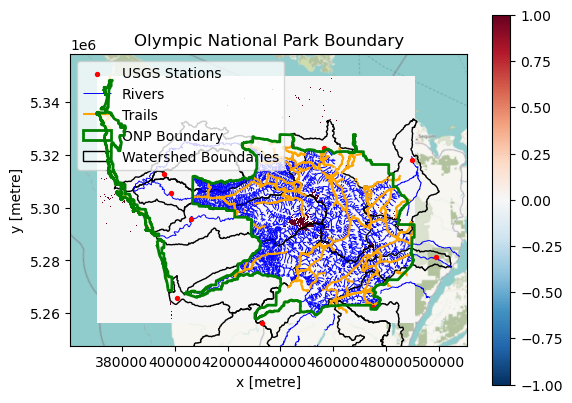

In [28]:
# plot everything together

fig, ax = plt.subplots()

# rgb_median_composite_2020.plot.imshow(ax=ax, robust=True)
snow_mask_2020.plot.imshow(ax=ax, cmap='RdBu_r', zorder=1, robust=True, vmin=-1, vmax=1)
stations_gdf.plot(ax=ax, marker='o', markersize = 8, color='red', zorder=5, label='USGS Stations')
rivers_gdf.plot(ax=ax, color='blue', linewidth=0.7, zorder=3, label='Rivers')
trails_gdf.plot(ax=ax, color='orange', zorder=4, label='Trails')
onp_gdf.plot(ax=ax, facecolor='None', edgecolor='green', linewidth=2, zorder=6, label='ONP Boundary')
watersheds_gdf.plot(ax=ax, facecolor='None', edgecolor='k', linewidth=1, zorder=2, label='Watershed Boundaries')
ax.set_title("Olympic National Park Boundary")
ctx.add_basemap(ax=ax, attribution = '', crs=onp_gdf.crs) 
# ax.grid(True)
ax.set_xlim(xmin-buffer, xmax+2*buffer)
ax.set_ylim(ymin-buffer, ymax+buffer)
ax.legend()

In [55]:
# determine extent of snow within each watershed - make a function and call for the list of watersheds in watersheds_gdf
def snow_extent_in_watershed(snow_mask, watershed): 
    snow_extent = snow_mask.where(snow_mask > 0.5)
    snow = snow_extent.rio.clip([watershed.geometry]) # snow within the watershed boundaries
    snow_pixels_in_watershed = int(snow_in_watershed.sum())
    res = 80
    area = snow_pixels_in_watershed*((res*res)/1E6) # area of snow in the watershed boundaries in km
    return snow, area

In [62]:
snow, area = snow_extent_in_watershed(snow_mask_2020, watersheds_gdf.loc[9])
print(f"There were {area:.2f} km^2 of snow in the {watersheds_gdf.Name.loc[9]} Watershed in 2020.")

There were 12.36 km^2 of snow in the Elwha River Watershed in 2020.


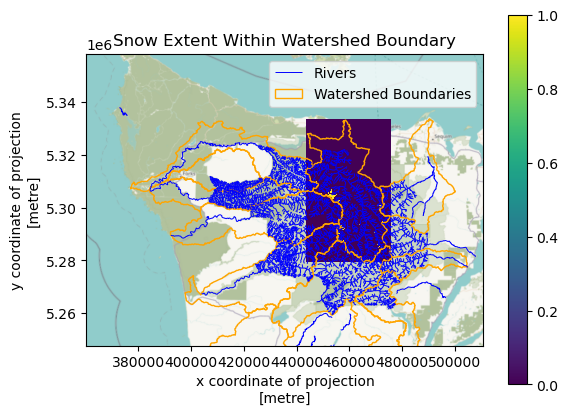

In [65]:
fig, ax = plt.subplots()
snow_in_watershed.plot.imshow(ax=ax,zorder=1)
# stations_gdf.plot(ax=ax, marker='o', markersize = 8, color='red', zorder=5, label='USGS Stations')
rivers_gdf.plot(ax=ax, color='blue', linewidth=0.7, zorder=3, label='Rivers')
# trails_gdf.plot(ax=ax, color='orange', zorder=4, label='Trails')
# onp_gdf.plot(ax=ax, facecolor='None', edgecolor='green', linewidth=2, zorder=6, label='ONP Boundary')
watersheds_gdf.plot(ax=ax, facecolor='None', edgecolor='orange', linewidth=1, zorder=2, label='Watershed Boundaries')
ax.set_title("Snow Extent Within Watershed Boundary")
ctx.add_basemap(ax=ax, attribution = '', crs=onp_gdf.crs) 
# ax.grid(True)
ax.set_xlim(xmin-buffer, xmax+2*buffer)
ax.set_ylim(ymin-buffer, ymax+buffer)
ax.legend()